<a href="https://colab.research.google.com/github/aiagentryk/Street_Vehicle_Detection_YOLO11/blob/main/Street_Vehicle_Detection_YOLO11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Street Vehicle Detection using YOLO11
**Classes:** Motorbike, Rickshaw, Car, Person  
**Pipeline:** Dataset → Preparation → Verification → YOLO11 → Training → Evaluation → Prediction → Results

## 1. Setup

In [2]:
# Install Ultralytics (official YOLO library)
!pip install -q ultralytics


In [3]:
import ultralytics

## 2. Load Dataset
Upload the Roboflow export `Street_Vehicle_Detection.v1i.yolov11.zip` (left sidebar → Files → upload) or use the cell below.

In [ ]:
# Option A: upload the zip directly from your computer
from google.colab import files
uploaded = files.upload()   # select Street_Vehicle_Detection.v1i.yolov11.zip

# Option B (if zip is on Google Drive): uncomment
# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/MyDrive/Street_Vehicle_Detection.v1i.yolov11.zip" /content/

In [4]:
# Unzip into /content/dataset
!rm -rf /content/dataset && mkdir -p /content/dataset
!unzip -q "/content/Street_Vehicle_Detection.v1i.yolov11.zip" -d /content/dataset
!ls /content/dataset

replace /content/dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
data.yaml  README.roboflow.txt	test  train  valid


## 3. Data Preparation & Verification

In [5]:
import os, glob, yaml

DATA_DIR = '/content/dataset'

# Roboflow's data.yaml often has relative paths like ../train/images which break in Colab.
# We read the class names and rewrite the yaml with absolute paths.
with open(f'{DATA_DIR}/data.yaml') as f:
    cfg = yaml.safe_load(f)

names = cfg['names']                      # list or dict of class names
if isinstance(names, dict):
    names = [names[k] for k in sorted(names)]
print('Classes:', names, '| Number of classes:', len(names))

# Roboflow names the validation folder 'valid'
splits = {}
for s, folder in [('train','train'), ('val','valid'), ('test','test')]:
    if os.path.isdir(f'{DATA_DIR}/{folder}/images'):
        splits[s] = f'{DATA_DIR}/{folder}/images'

new_cfg = {'path': DATA_DIR, 'names': names, 'nc': len(names), **splits}
with open(f'{DATA_DIR}/data_fixed.yaml', 'w') as f:
    yaml.dump(new_cfg, f)
DATA_YAML = f'{DATA_DIR}/data_fixed.yaml'
print(open(DATA_YAML).read())

Classes: ['Car', 'Motorbike', 'Person', 'Rickshaw'] | Number of classes: 4
names:
- Car
- Motorbike
- Person
- Rickshaw
nc: 4
path: /content/dataset
test: /content/dataset/test/images
train: /content/dataset/train/images
val: /content/dataset/valid/images



In [6]:
# Dataset verification: image/label counts per split and split percentages
import pandas as pd
rows = []
for s, folder in [('train','train'), ('val','valid'), ('test','test')]:
    imgs = glob.glob(f'{DATA_DIR}/{folder}/images/*')
    lbls = glob.glob(f'{DATA_DIR}/{folder}/labels/*.txt')
    if imgs:
        rows.append({'split': s, 'images': len(imgs), 'label_files': len(lbls)})
df = pd.DataFrame(rows)
df['percent'] = (df['images'] / df['images'].sum() * 100).round(1)
print(df.to_string(index=False))
print('\nTotal images:', df['images'].sum())

split  images  label_files  percent
train     352          352     87.6
  val      33           33      8.2
 test      17           17      4.2

Total images: 402


{'Car': 374, 'Motorbike': 438, 'Person': 211, 'Rickshaw': 228} | Total boxes: 1251


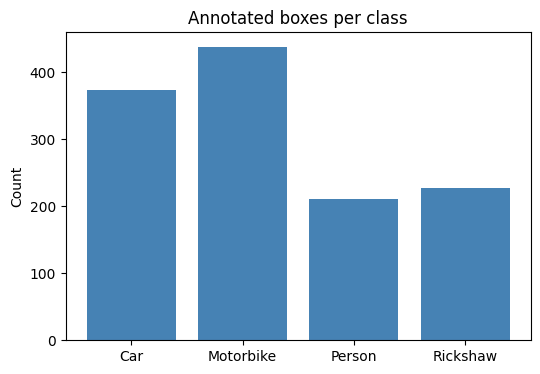

In [7]:
# Count bounding boxes per class (checks for class imbalance)
from collections import Counter
import matplotlib.pyplot as plt

counts = Counter()
for lf in glob.glob(f'{DATA_DIR}/*/labels/*.txt'):
    for line in open(lf):
        parts = line.split()
        if parts:
            counts[names[int(parts[0])]] += 1

print(dict(counts), '| Total boxes:', sum(counts.values()))
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title('Annotated boxes per class'); plt.ylabel('Count'); plt.show()

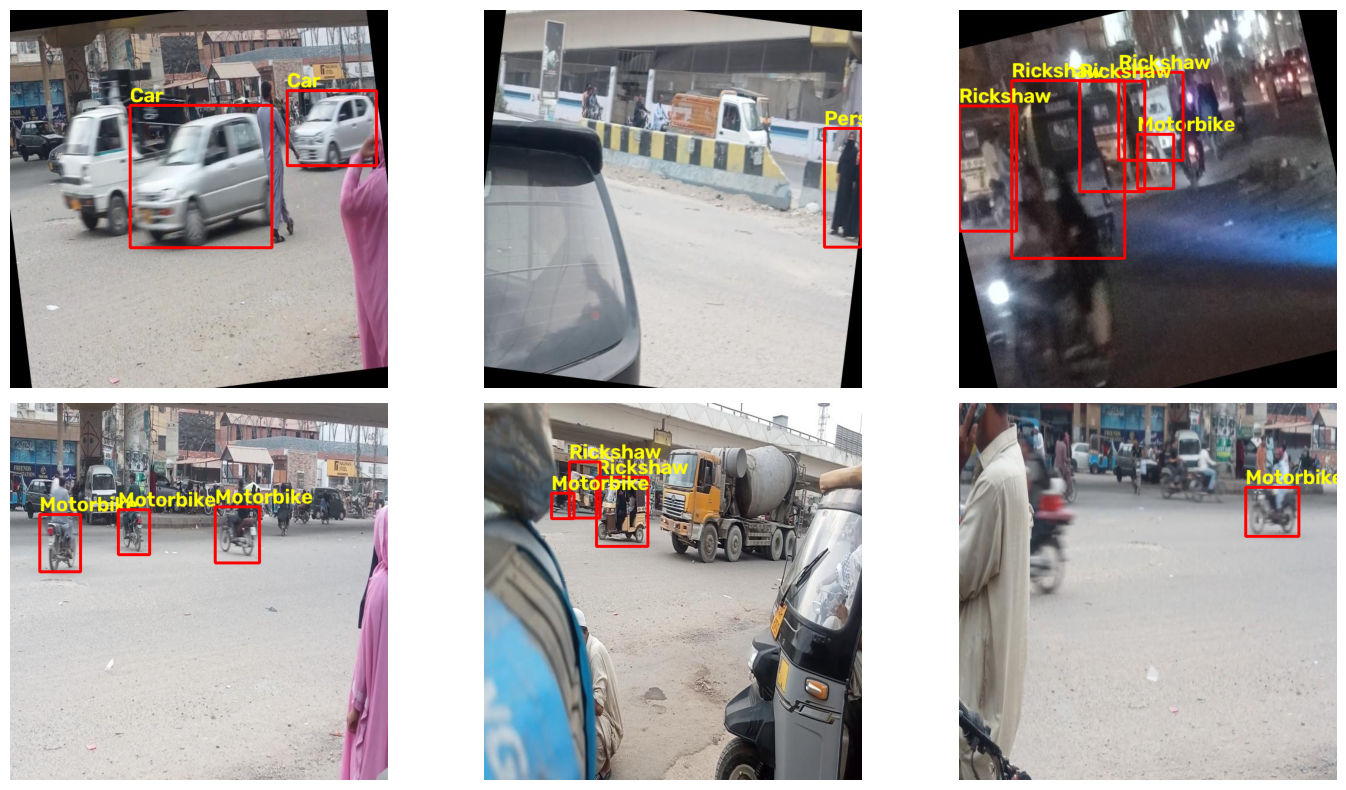

In [8]:
# Visualize a few annotated training images to confirm labels look correct
import cv2, random
def show_labeled(n=6):
    imgs = random.sample(glob.glob(f'{DATA_DIR}/train/images/*'), n)
    plt.figure(figsize=(15,8))
    for i, p in enumerate(imgs):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lp = p.replace('/images/', '/labels/').rsplit('.',1)[0] + '.txt'
        if os.path.exists(lp):
            for line in open(lp):
                c, x, y, bw, bh = line.split()[:5]
                x, y, bw, bh = float(x)*w, float(y)*h, float(bw)*w, float(bh)*h
                x1, y1, x2, y2 = int(x-bw/2), int(y-bh/2), int(x+bw/2), int(y+bh/2)
                cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 3)
                cv2.putText(img, names[int(c)], (x1, max(y1-5,15)), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,255,0), 3)
        plt.subplot(2,3,i+1); plt.imshow(img); plt.axis('off')
    plt.tight_layout(); plt.show()
show_labeled()

## 4. YOLO Model & Training

In [9]:
from ultralytics import YOLO

# Training parameters (record these in your report)
MODEL     = 'yolo11n.pt'   # nano = fastest; use yolo11s.pt for higher accuracy if time allows
EPOCHS    = 60
IMGSZ     = 640
BATCH     = 16

model = YOLO(MODEL)        # loads COCO-pretrained weights (transfer learning)

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    patience=20,           # early stopping if no improvement
    project='/content/runs',
    name='city_vehicles',
    exist_ok=True,
    plots=True             # saves confusion matrix, PR curves, loss curves
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=karachi_vehicles, nbs=64, nms=None, opset=None, optimize=F

## 5. Evaluation

In [10]:
# Load the best weights and evaluate on validation set
best = YOLO('/content/runs/city_vehicles/weights/best.pt')
m = best.val(data=DATA_YAML, split='val')

print(f'Precision : {m.box.mp:.3f}')
print(f'Recall    : {m.box.mr:.3f}')
print(f'mAP@50    : {m.box.map50:.3f}')
print(f'mAP@50-95 : {m.box.map:.3f}')

# Per-class results (useful for discussing weak classes like Person)
print('\nPer-class:')
for i, c in enumerate(m.box.ap_class_index):
    print(f'{names[c]:10s} P={m.box.p[i]:.3f}  R={m.box.r[i]:.3f}  mAP50={m.box.ap50[i]:.3f}  mAP50-95={m.box.ap[i]:.3f}')

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1190.1±523.3 MB/s, size: 40.0 KB)
val: Scanning /content/dataset/valid/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 8.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         33        110      0.621      0.631      0.594      0.346
                   Car         23         38       0.58      0.654      0.615      0.377
             Motorbike         19         33      0.594      0.576      0.542      0.311
                Person         11         18      0.635      0.581      0.545      0.268
              Rickshaw         17         21      0.675      0.714      0.674       0.43
Speed: 7.1ms preprocess, 35.2ms inference, 0.0ms lo

In [11]:
# Evaluate on the held-out TEST split (if it exists)
if 'test' in splits:
    mt = best.val(data=DATA_YAML, split='test')
    print(f'TEST -> P={mt.box.mp:.3f} R={mt.box.mr:.3f} mAP50={mt.box.map50:.3f} mAP50-95={mt.box.map:.3f}')

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1591.3±471.5 MB/s, size: 51.8 KB)
val: Scanning /content/dataset/test/labels... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 2.1Kit/s 0.0s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.3it/s 0.6s
                   all         17         51      0.605       0.52      0.538      0.327
                   Car         10         15      0.601      0.704      0.681      0.414
             Motorbike         10         18      0.401        0.5      0.491      0.295
                Person          7         10      0.734        0.5      0.603      0.309
              Rickshaw          8          8      0.685      0.375      0.375       0.29


results.png


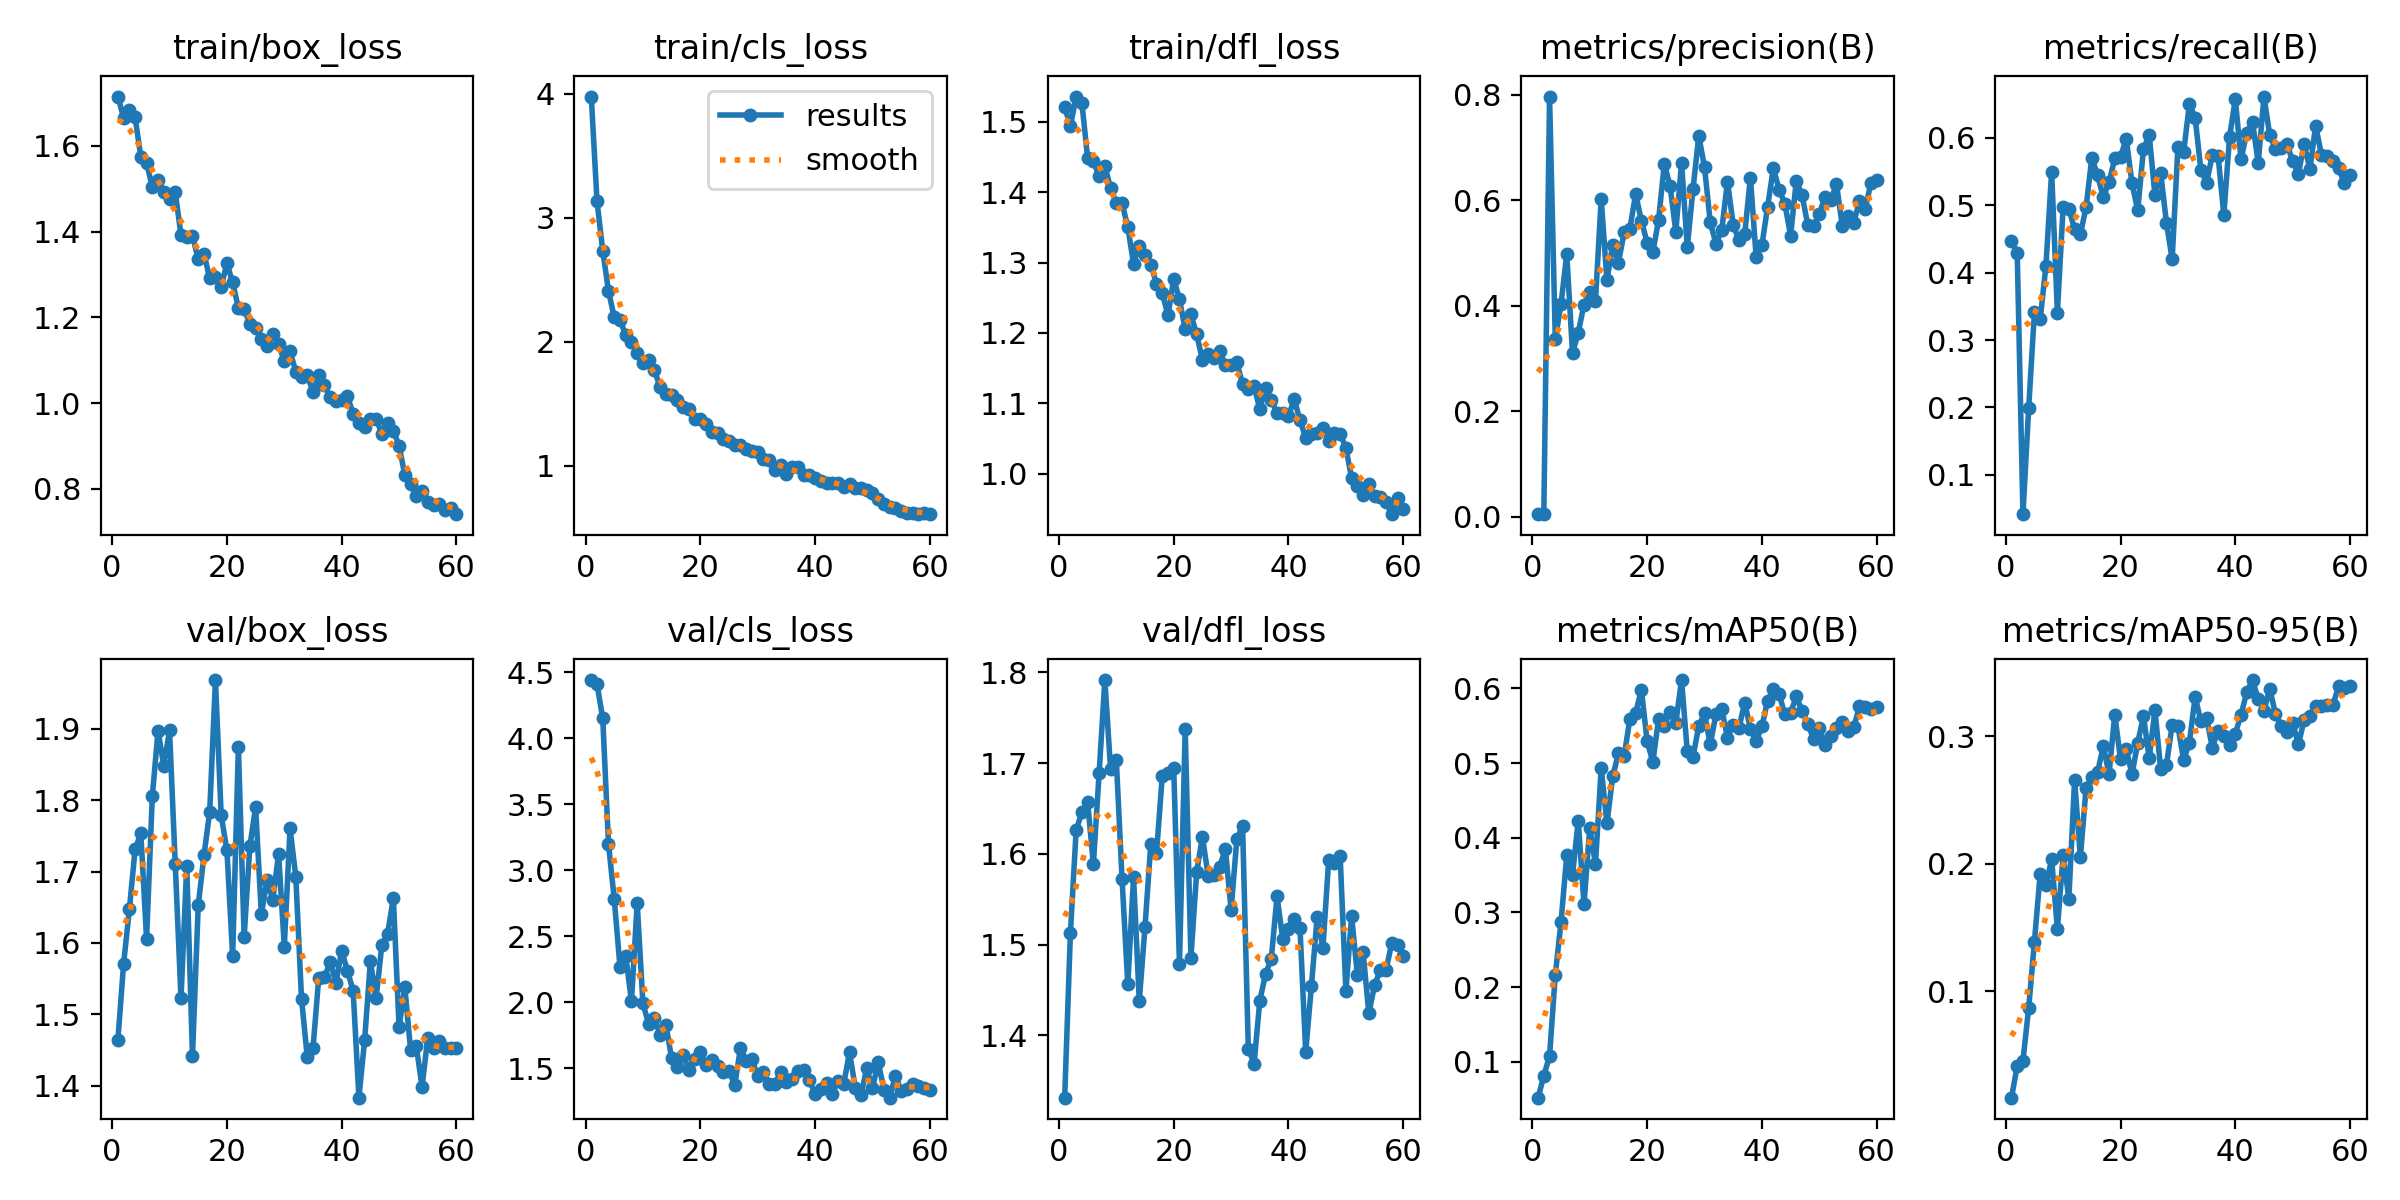


confusion_matrix.png


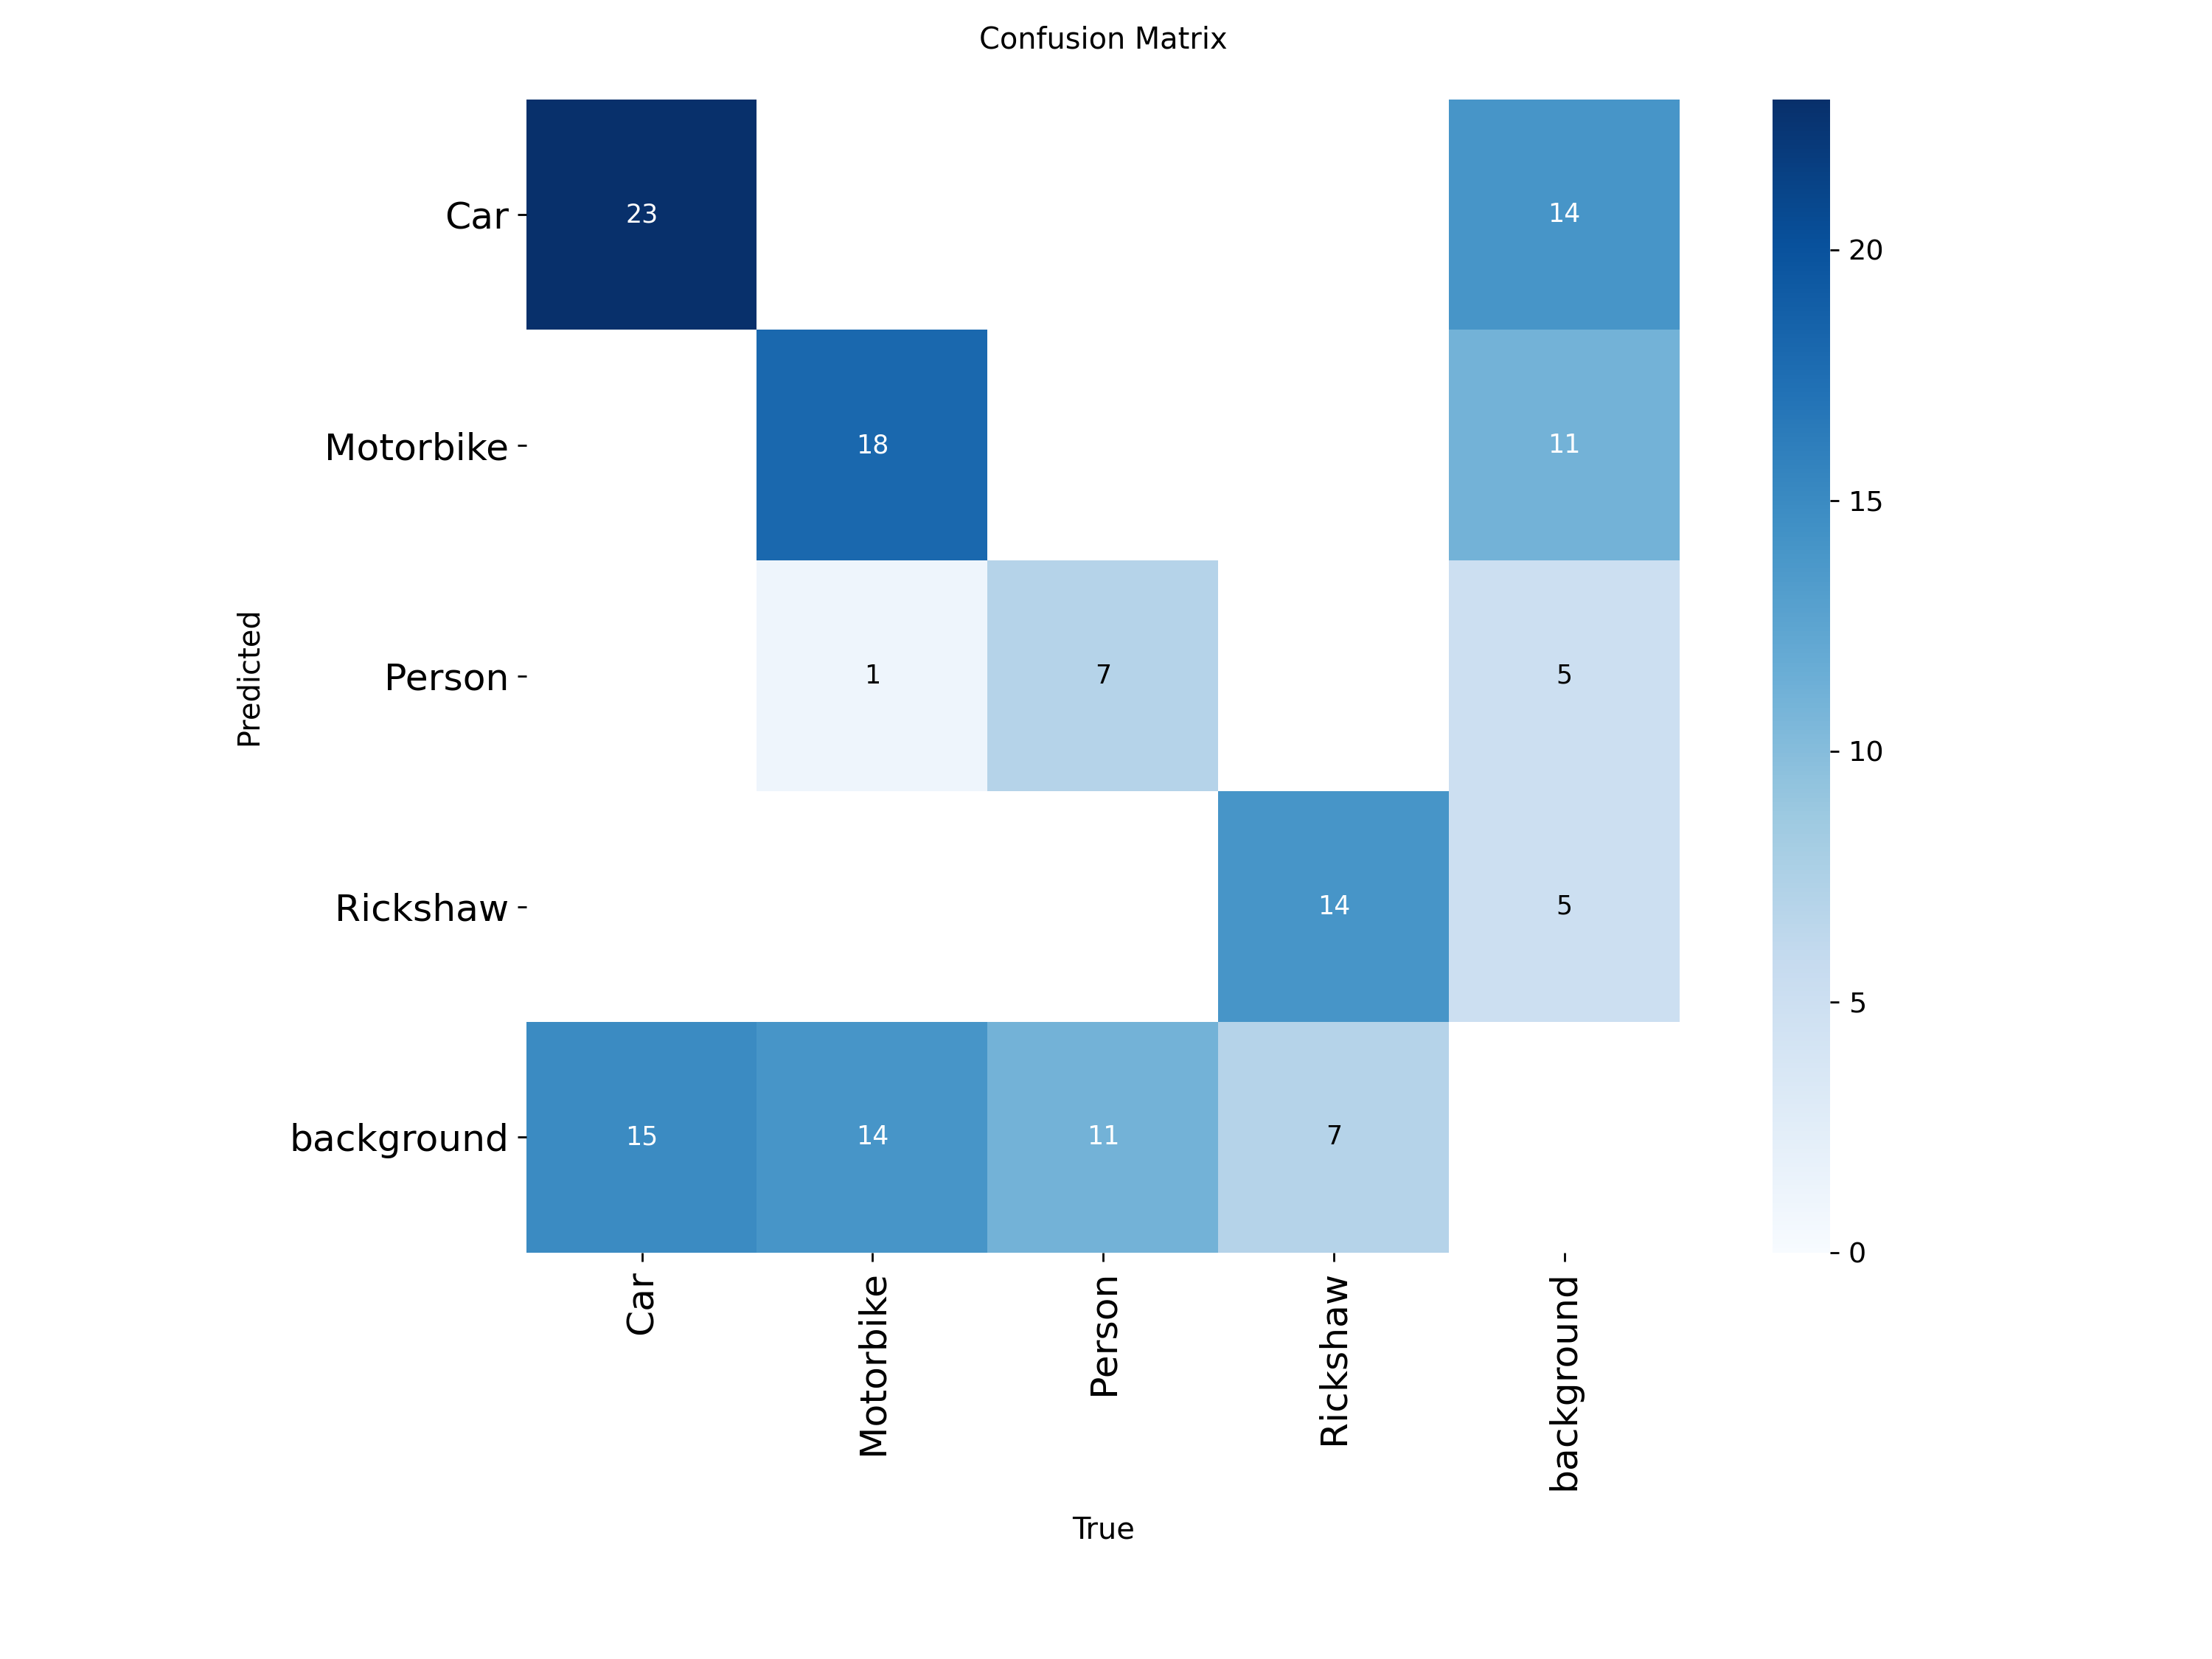


confusion_matrix_normalized.png


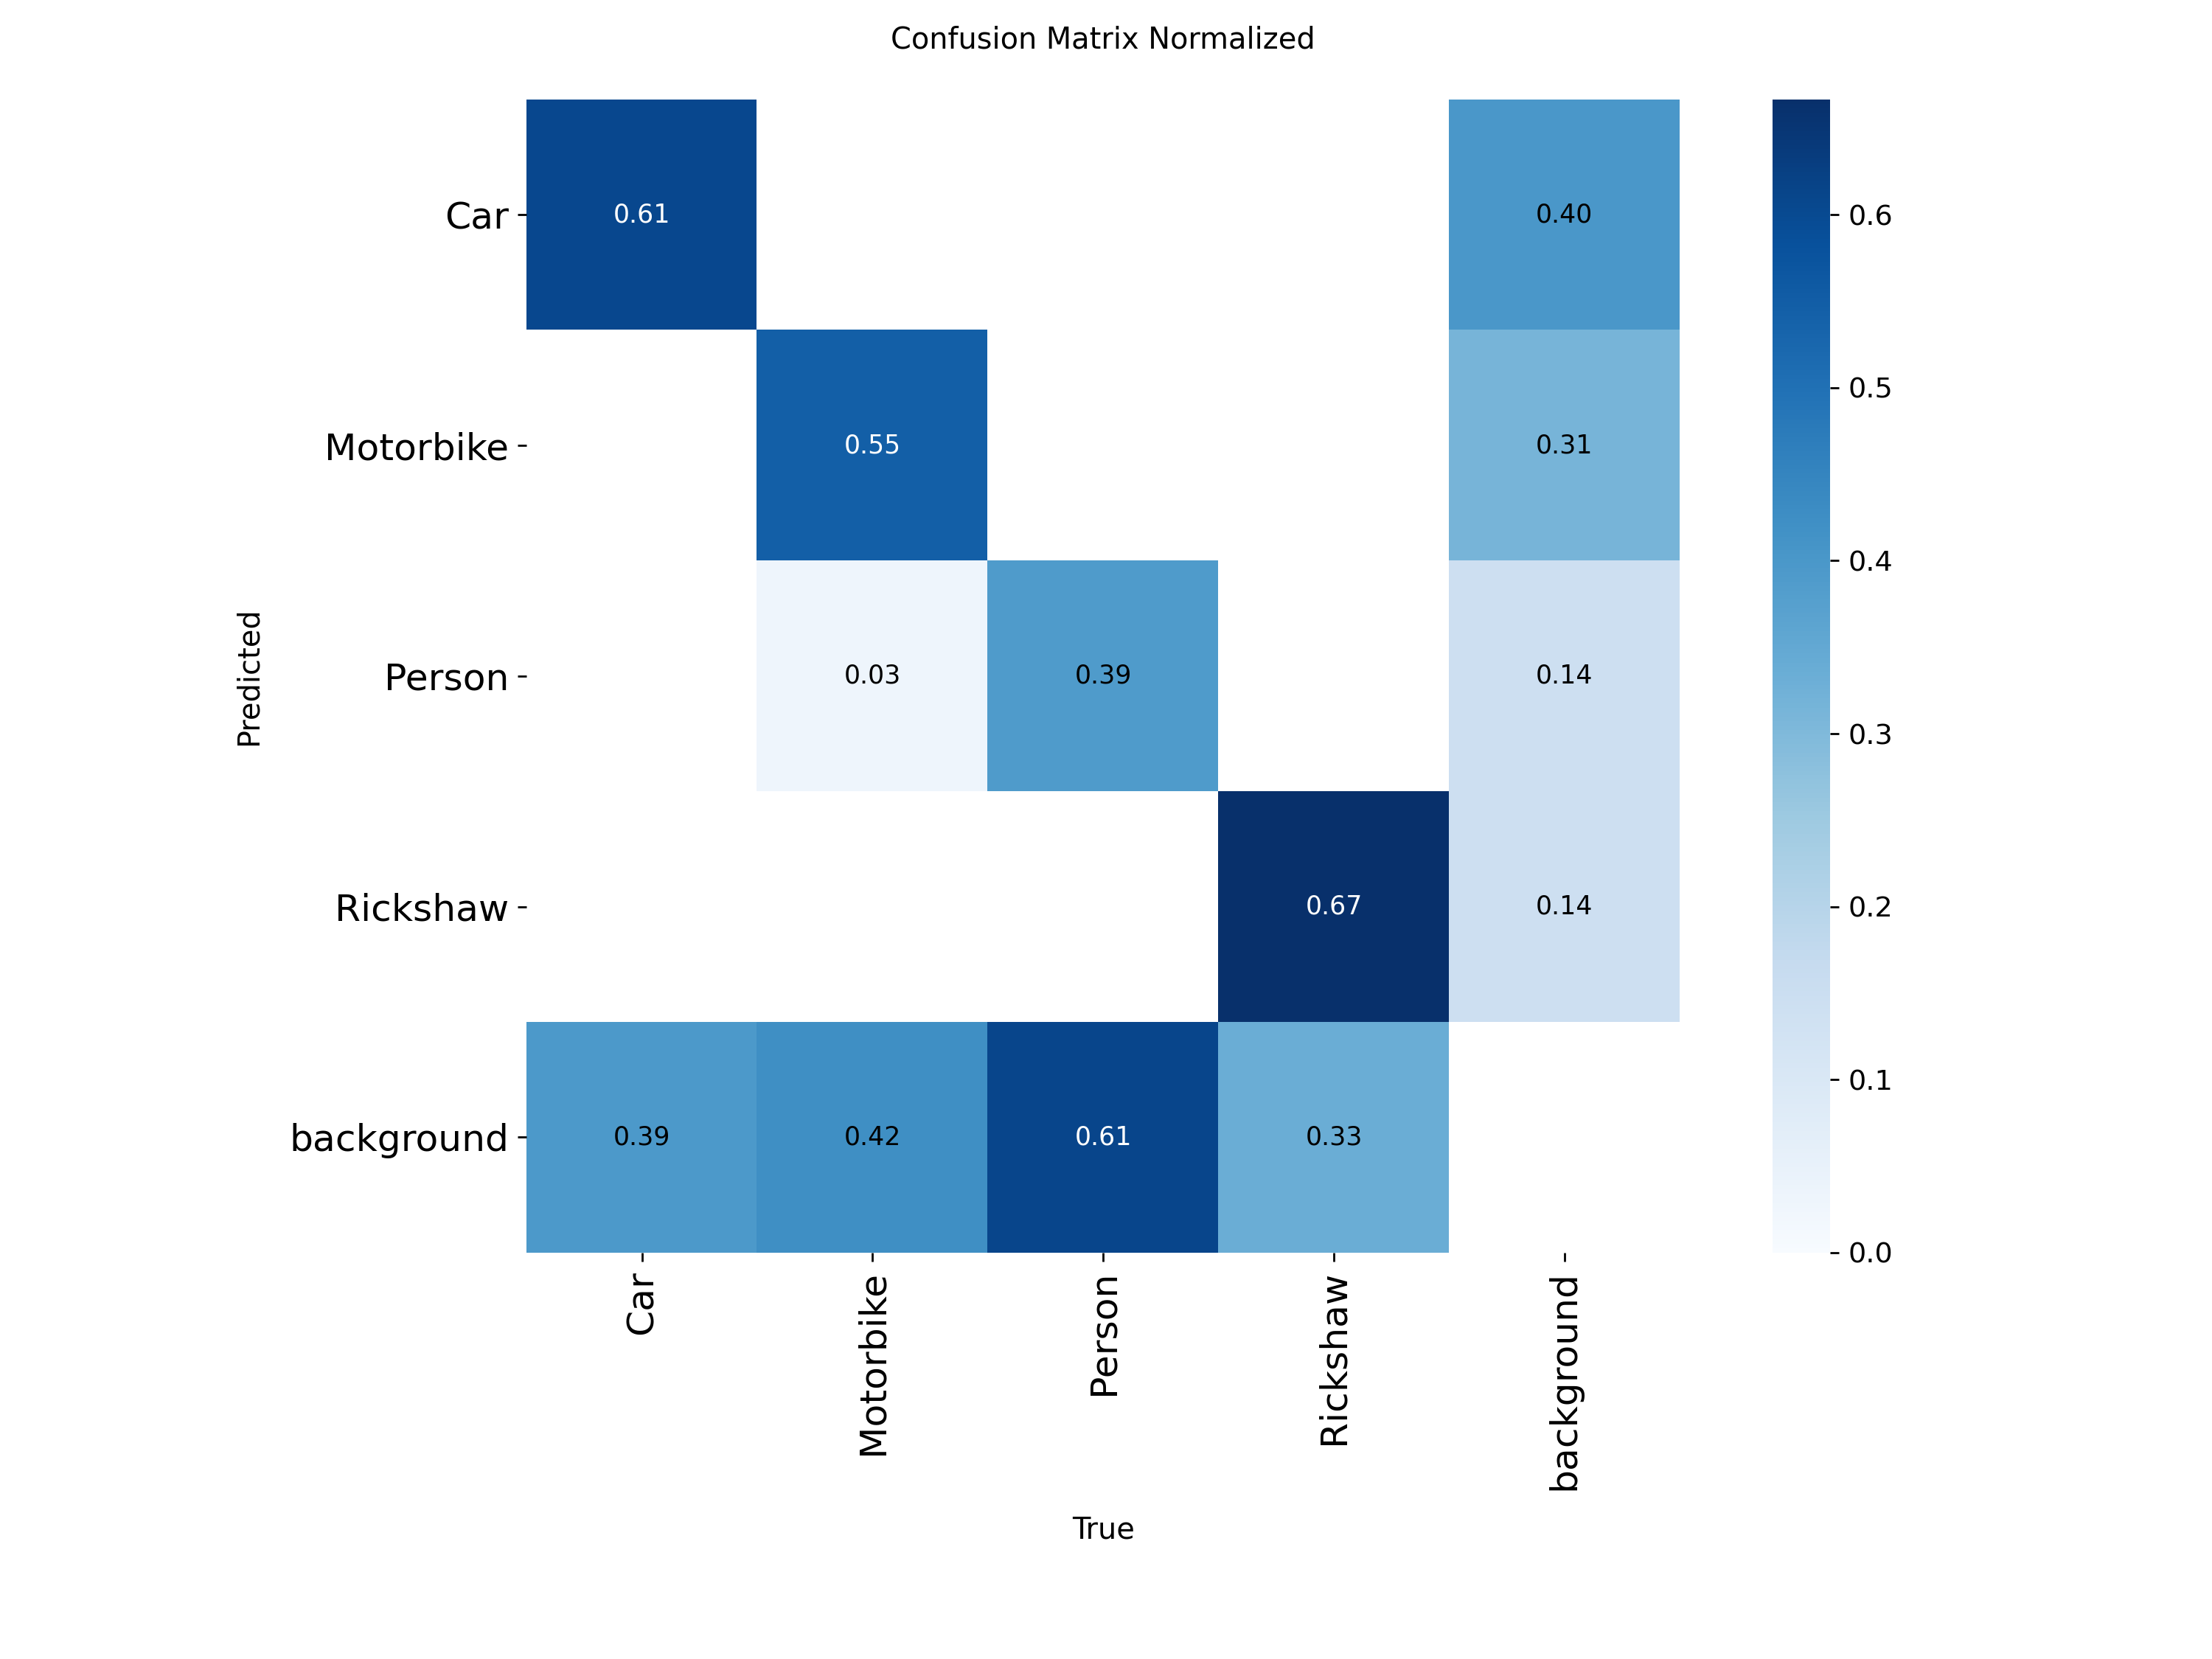


BoxPR_curve.png


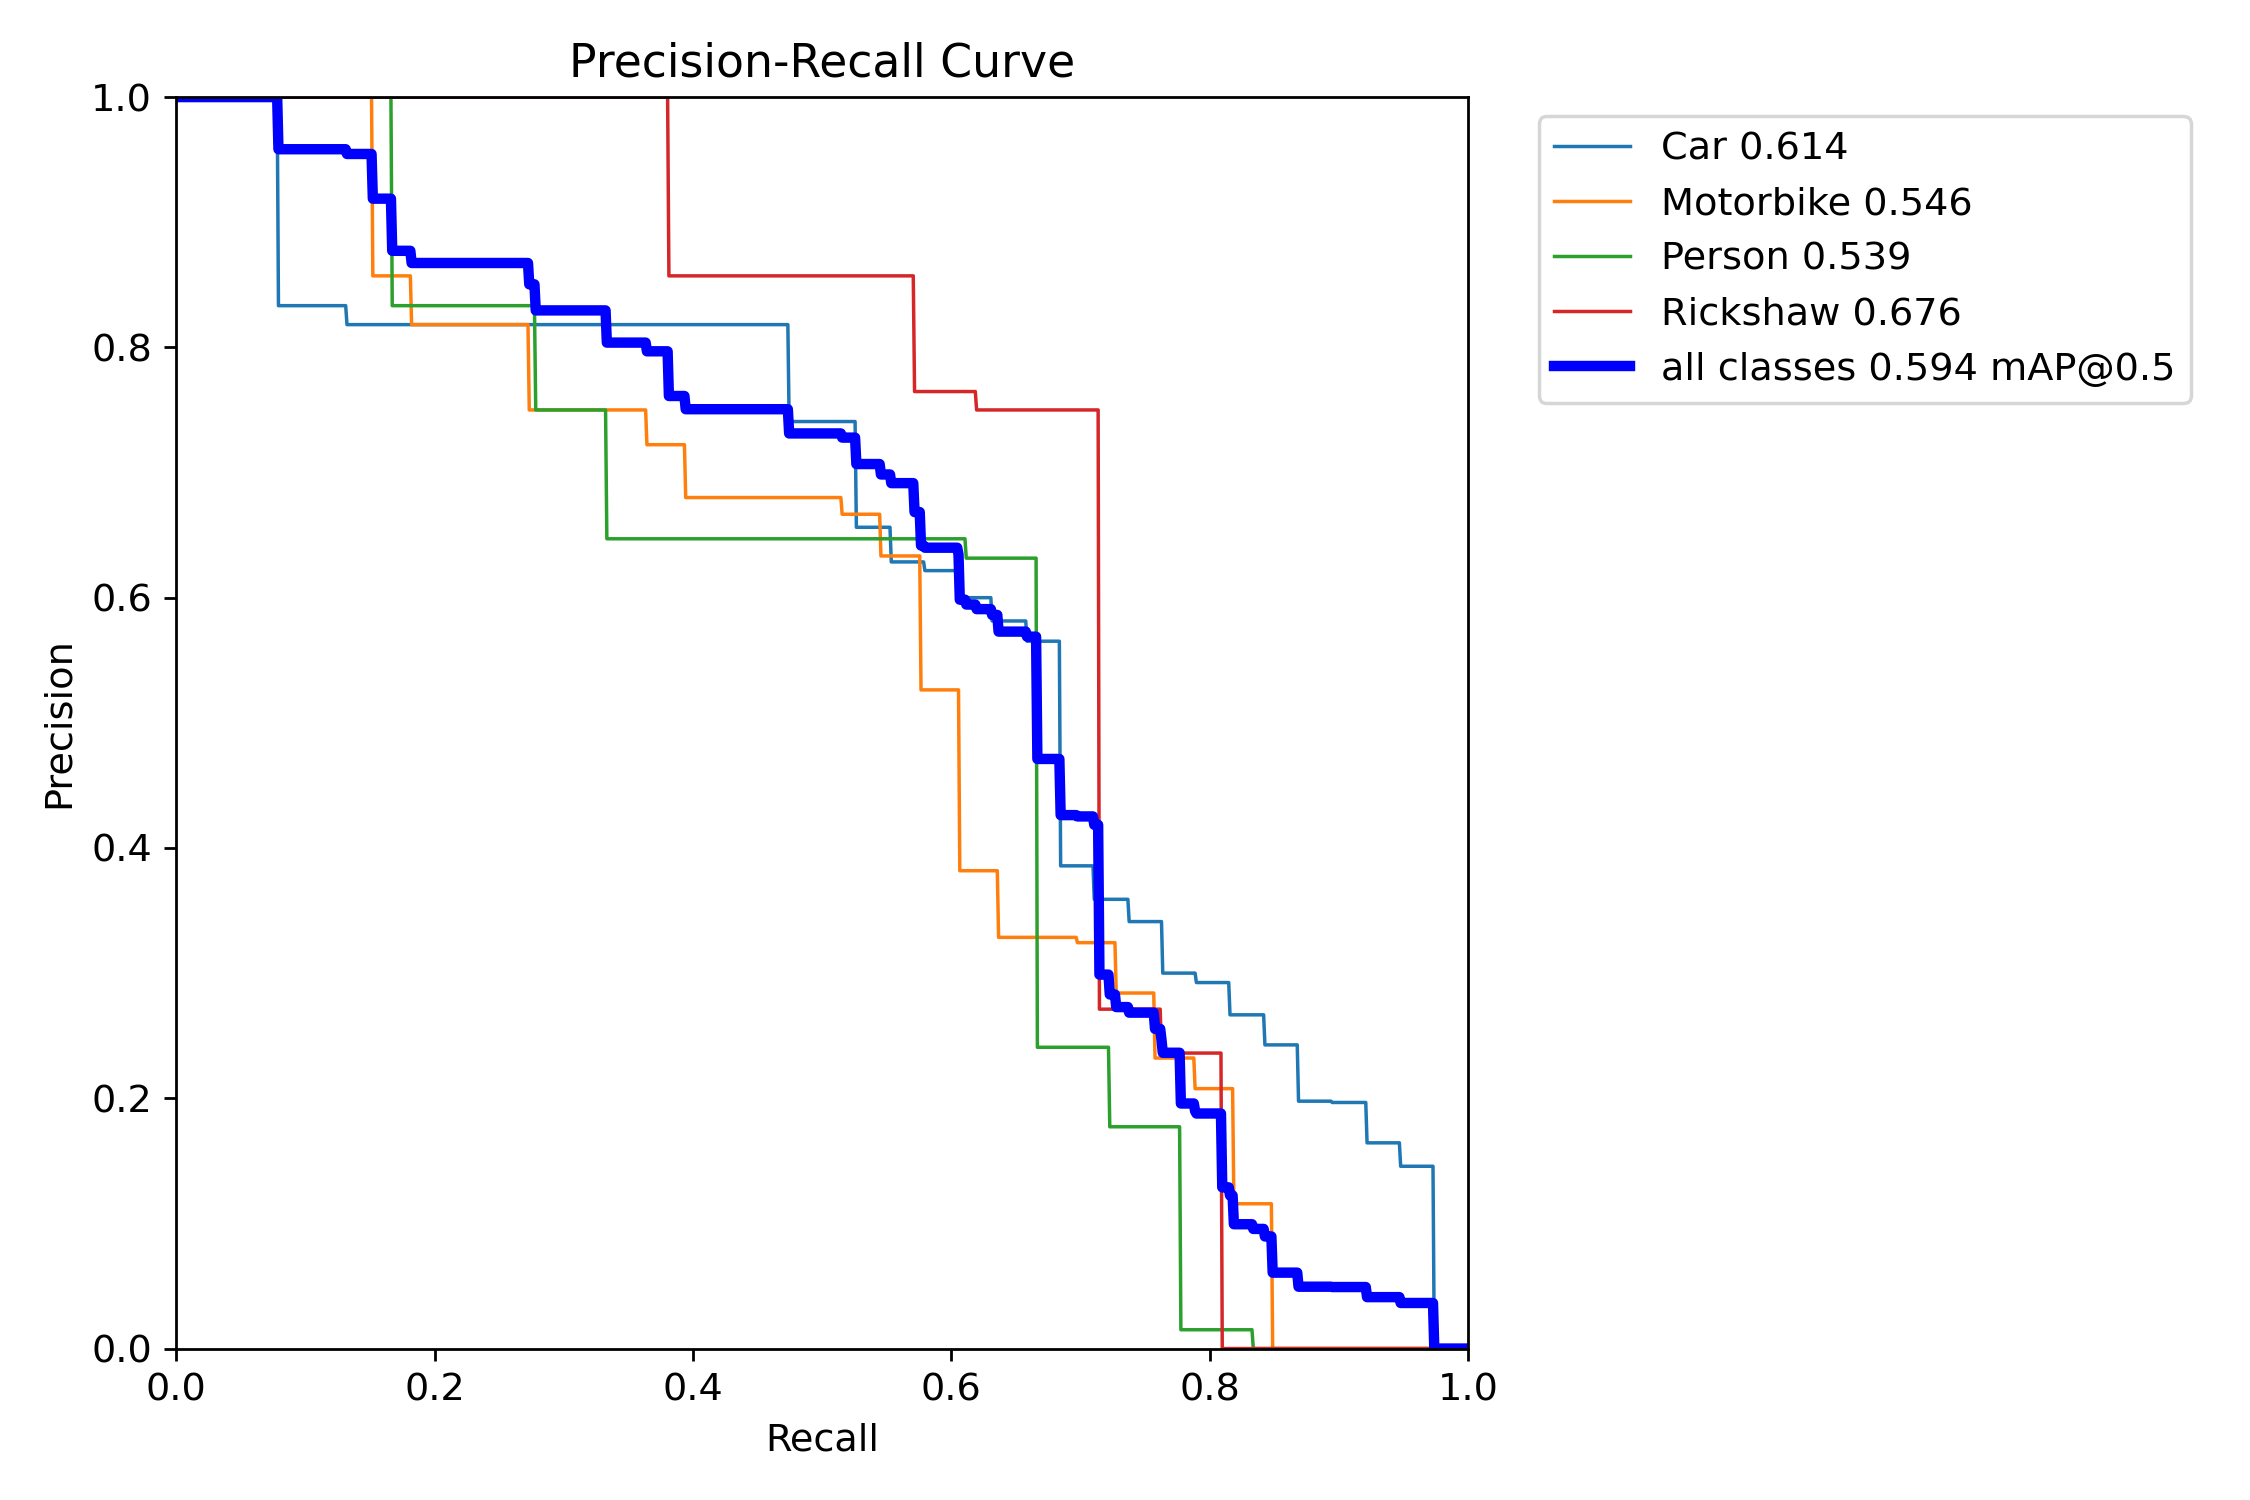


BoxP_curve.png


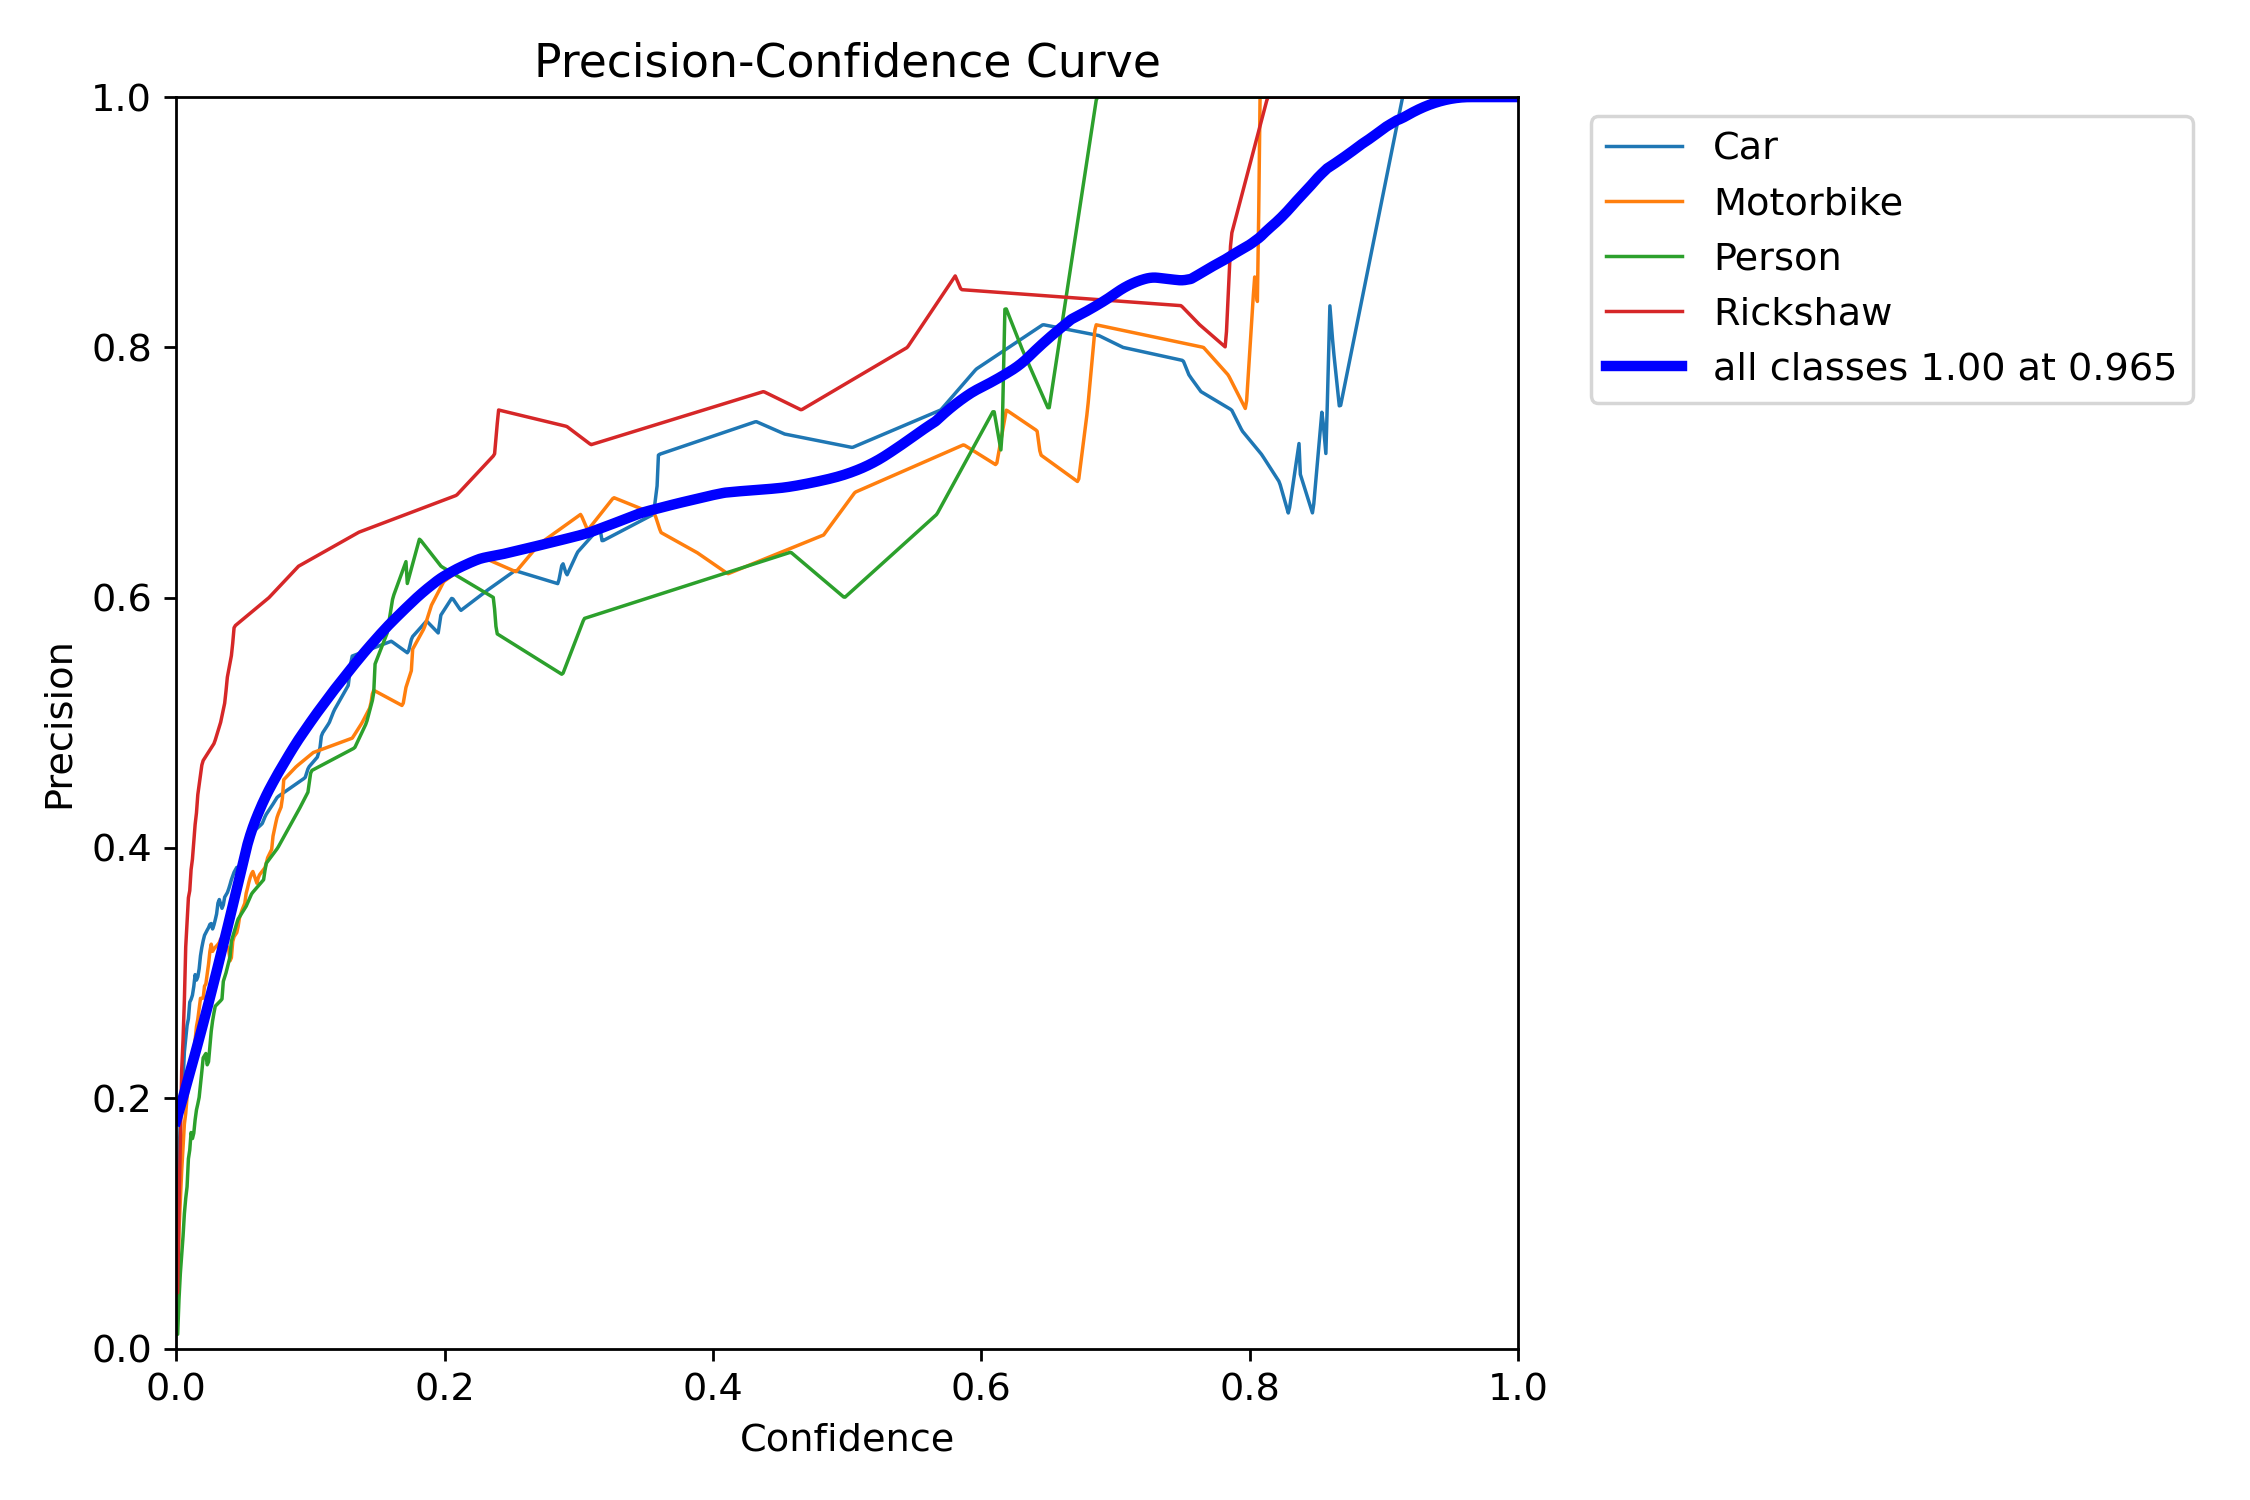


BoxR_curve.png


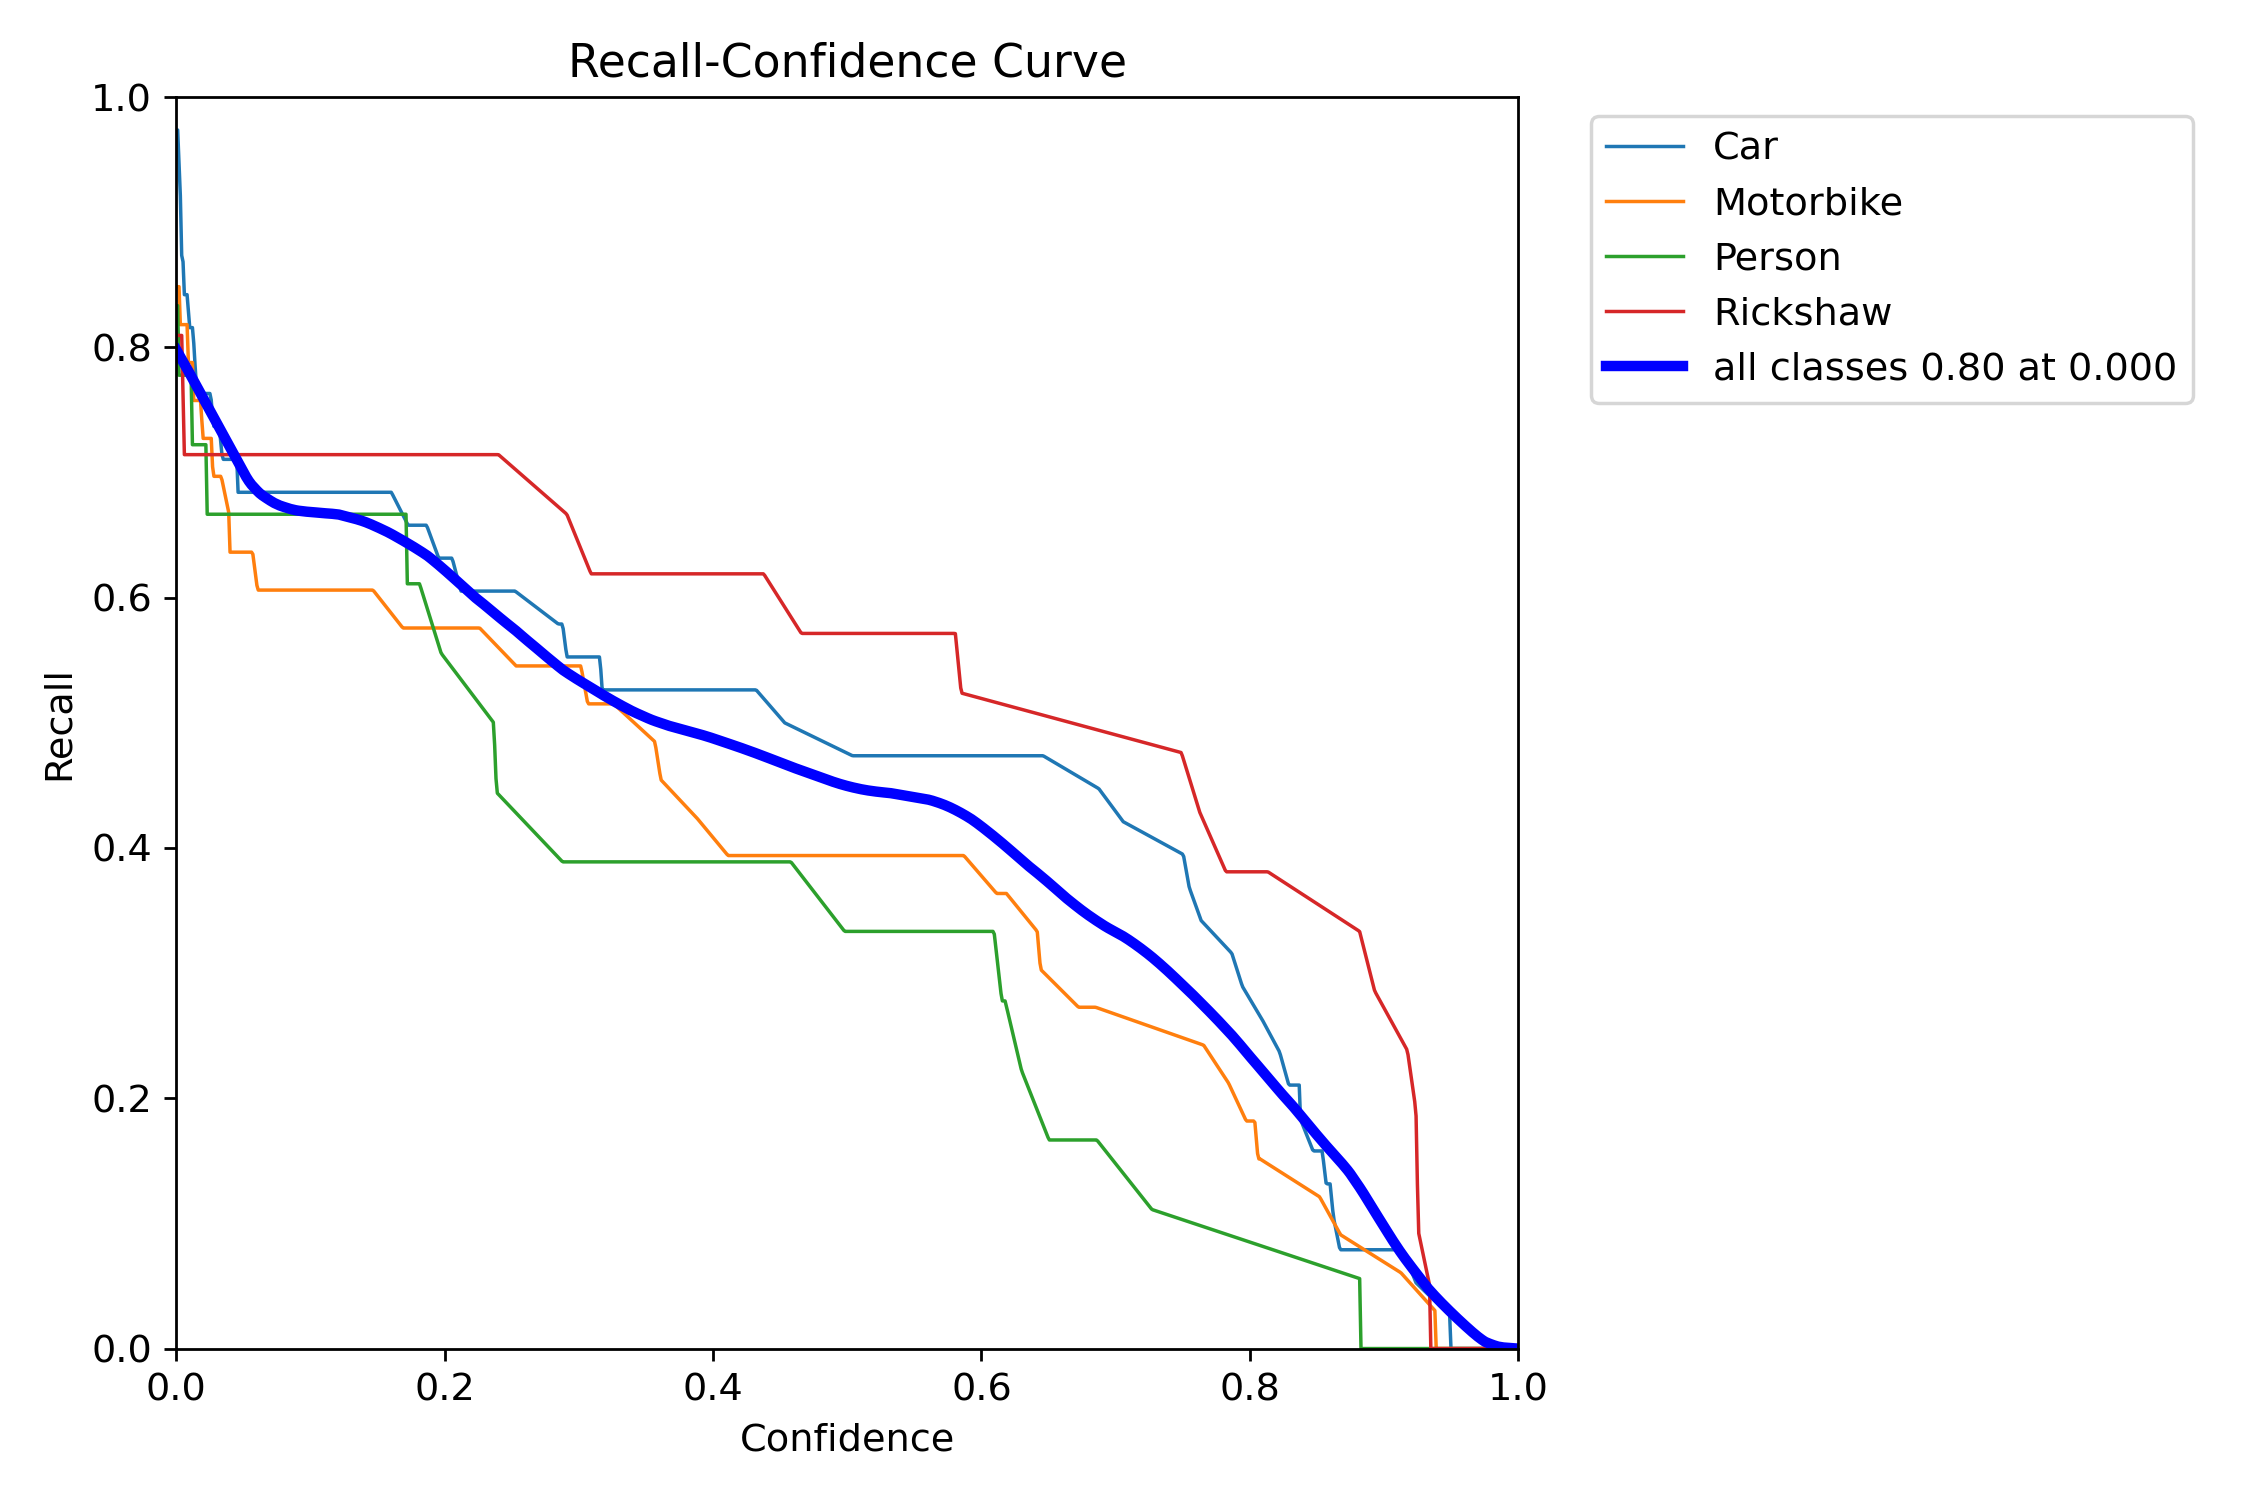


BoxF1_curve.png


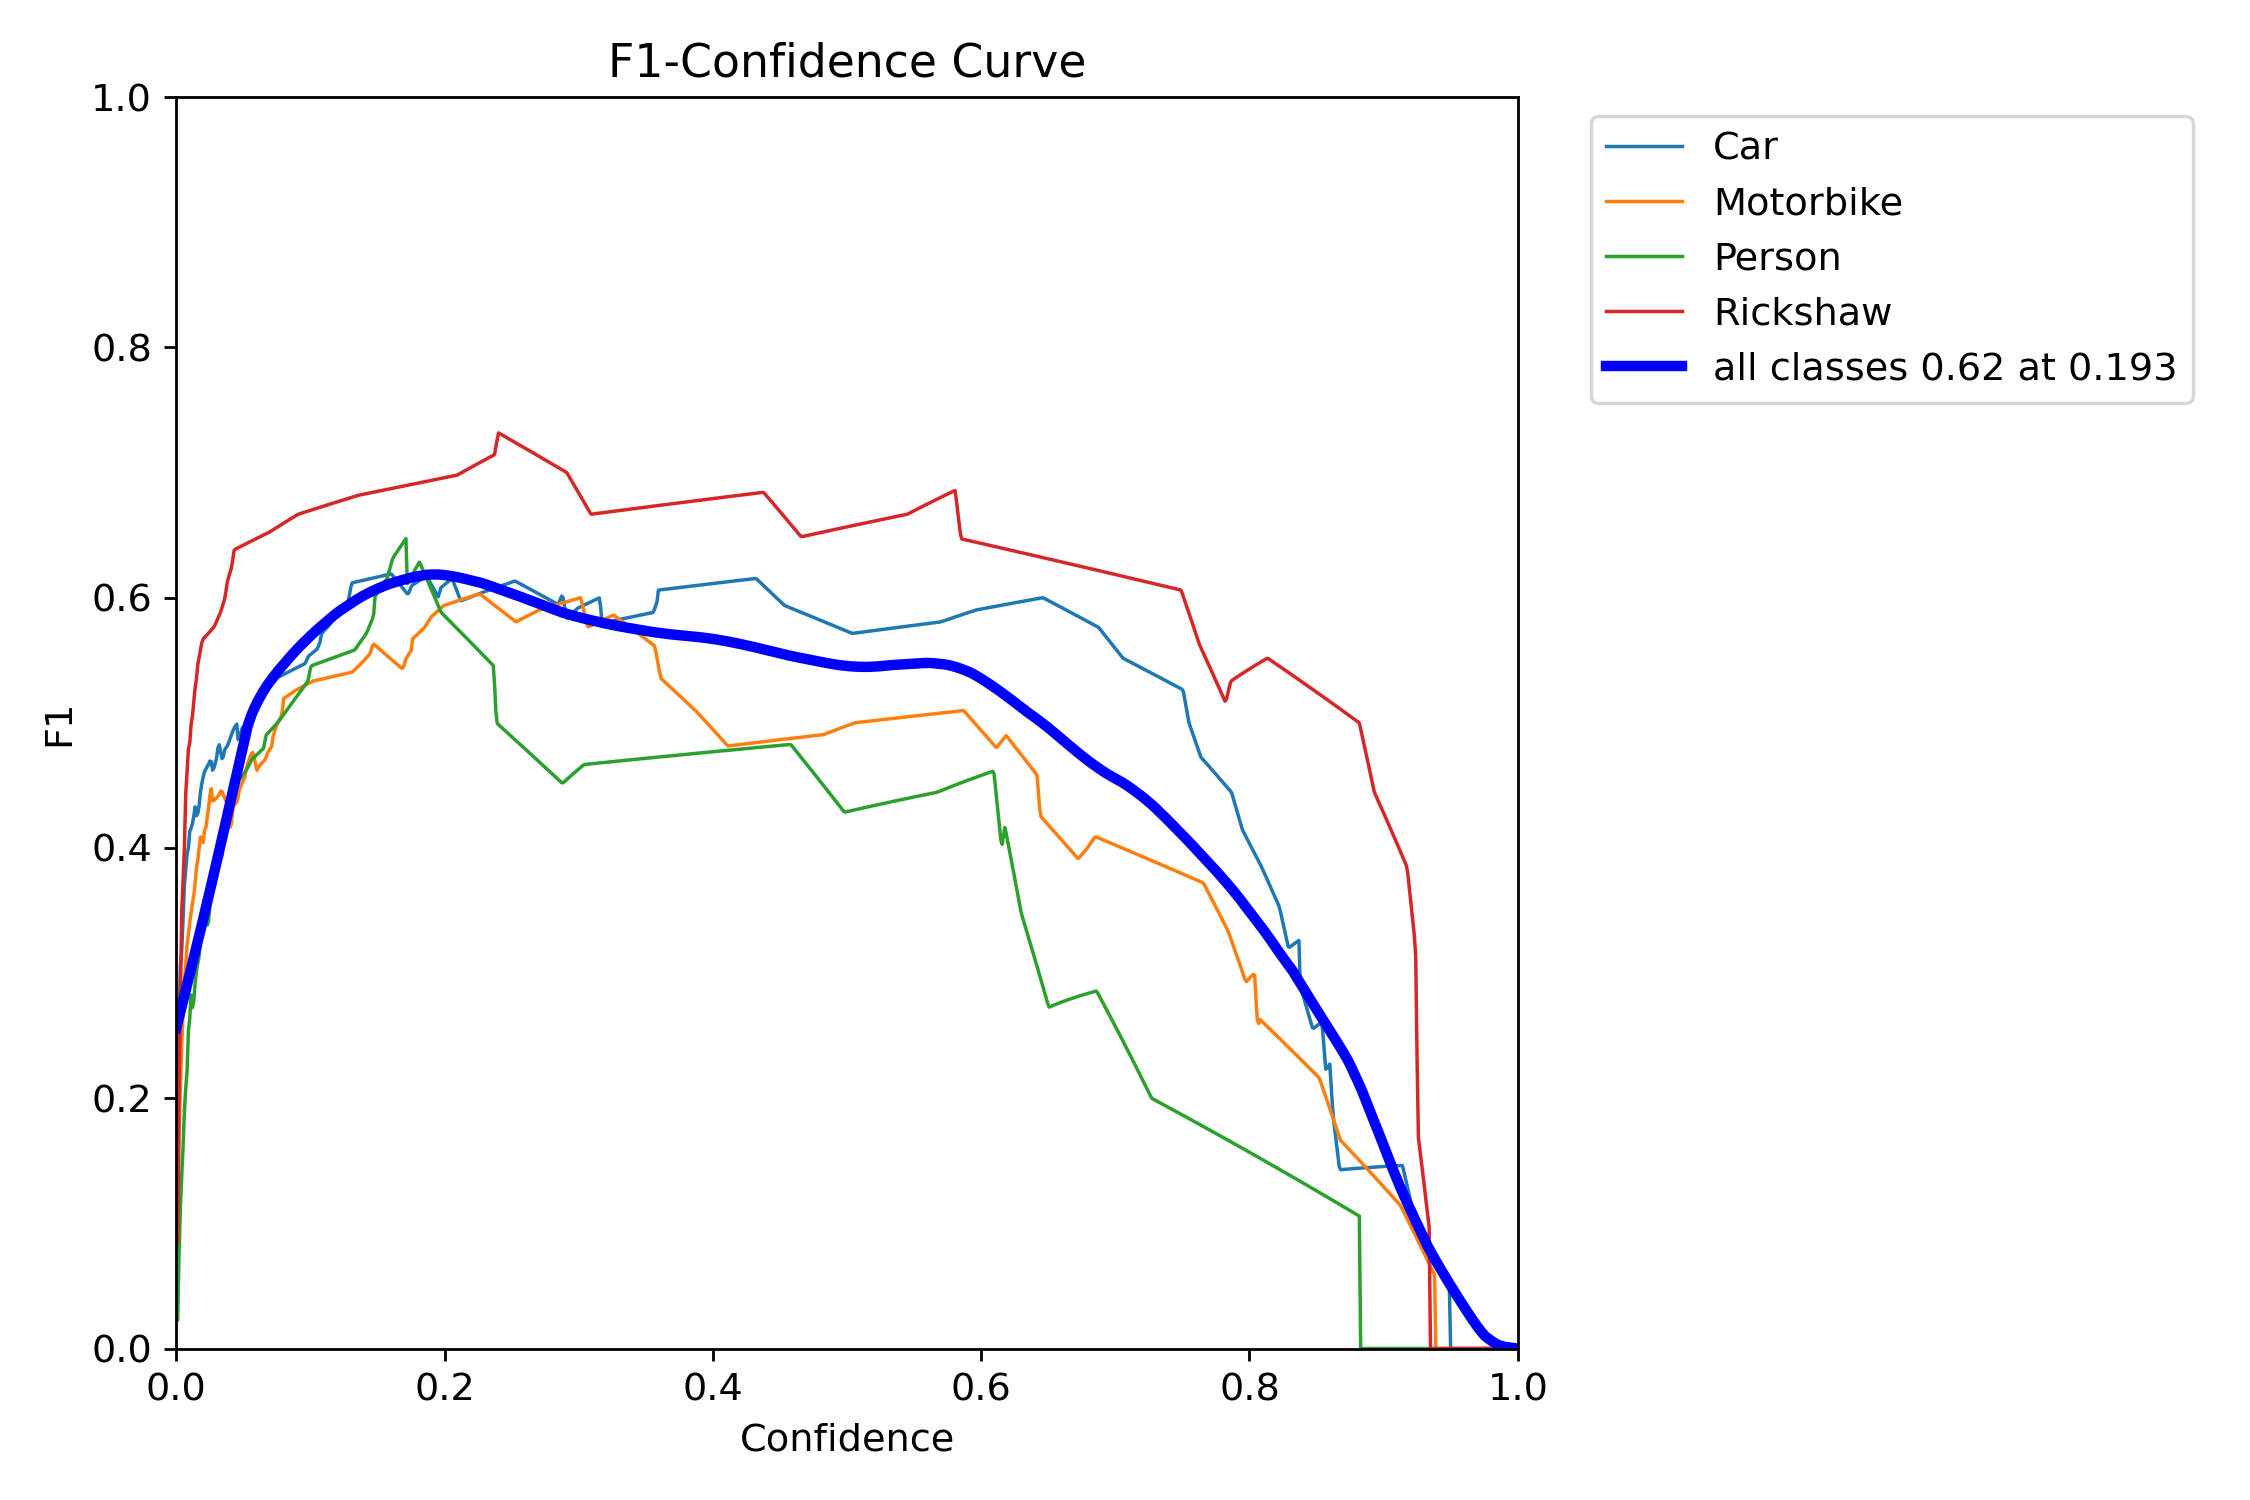

In [12]:
# Display training graphs & confusion matrix saved by Ultralytics
from IPython.display import Image, display
RUN = '/content/runs/city_vehicles'
for f in ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png',
          'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'BoxF1_curve.png']:
    if os.path.exists(f'{RUN}/{f}'):
        print('\n' + f); display(Image(f'{RUN}/{f}', width=800))

**How to explain the graphs in your report**
- **results.png:** train/val box loss, cls loss, dfl loss should fall over epochs; if val loss rises while train loss falls → overfitting.
- **Precision / Recall / mAP curves:** should rise and plateau; plateau means training has converged.
- **Confusion matrix:** diagonal = correct detections; off-diagonal shows class confusion (e.g. Car vs Rickshaw); the *background* row/column shows missed objects and false positives.
- **PR curve:** the closer to the top-right, the better; compare classes (Person is usually lowest).

## 6. Prediction on Unseen Images

In [17]:
import gradio as gr

In [21]:
def prediction_image(image):
  prediction  = best.predict(image)
  return prediction[0].plot()

In [22]:
app = gr.Interface(fn =prediction_image, inputs=["image","video"], outputs=["image","video"], title = "YOLO MODEL PREDICTION" )

/usr/local/lib/python3.13/dist-packages/gradio/utils.py:1279: UserWarning: Expected 1 arguments for function <function prediction_image at 0x7b6077f6f240>, received 2.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/gradio/utils.py:1287: UserWarning: Expected maximum 1 arguments for function <function prediction_image at 0x7b6077f6f240>, received 2.
  warnings.warn(


In [23]:
app.launch(inbrowser=True, inline=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://05dd31e5f0d8d14eab.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
# Predict on test images (unseen during training). conf = minimum confidence threshold
test_dir = splits.get('test', splits['val'])
preds = best.predict(source=test_dir, conf=0.25, save=True,
                     project='/content/runs', name='predictions', exist_ok=True)
print('Saved to /content/runs/predictions')


image 1/17 /content/dataset/test/images/Vehicle_mp4-0006_jpg.rf.0459b60616b5fb02625b7dab72fd8051.jpg: 640x640 2 Cars, 12 Motorbikes, 7.8ms
image 2/17 /content/dataset/test/images/Vehicle_mp4-0006_jpg.rf.d42106c89e79c4b1eb3476e4ad0d67a7.jpg: 640x640 (no detections), 8.7ms
image 3/17 /content/dataset/test/images/Vehicle_mp4-0015_jpg.rf.fe2ea61fad9280483403695dacaa3e00.jpg: 640x640 2 Motorbikes, 1 Rickshaw, 10.1ms
image 4/17 /content/dataset/test/images/Vehicle_mp4-0020_jpg.rf.347e0b3755c903dd2bbd6d961c9d65c0.jpg: 640x640 5 Cars, 4 Motorbikes, 2 Persons, 8.4ms
image 5/17 /content/dataset/test/images/Vehicle_mp4-0023_jpg.rf.7275520a48efc528a4c4196300211fe0.jpg: 640x640 5 Cars, 1 Rickshaw, 9.3ms
image 6/17 /content/dataset/test/images/Vehicle_mp4-0033_jpg.rf.bd2af4c24dcaca11570d18c91bb74b6d.jpg: 640x640 2 Cars, 5 Motorbikes, 8.4ms
image 7/17 /content/dataset/test/images/Vehicle_mp4-0051_jpg.rf.6cfd83dabf40fd06d61e379d276f9e9d.jpg: 640x640 (no detections), 8.1ms
image 8/17 /content/dataset/

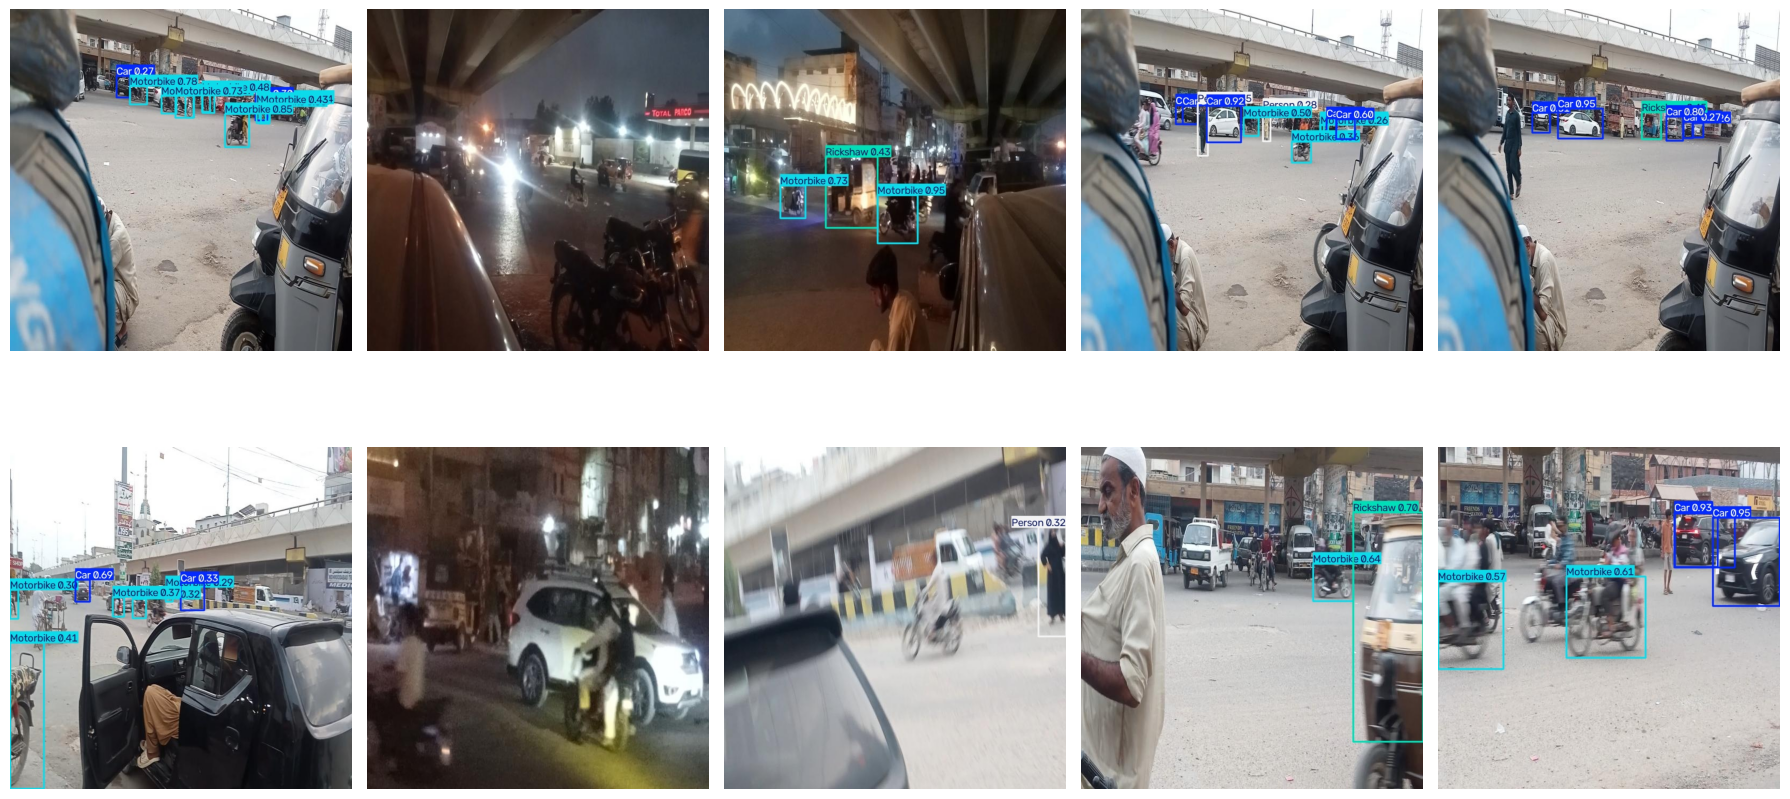

In [14]:
# Show 10 prediction examples (boxes + class names + confidence scores)
pred_imgs = sorted(glob.glob('/content/runs/predictions/*.jpg'))[:10]
plt.figure(figsize=(18,10))
for i, p in enumerate(pred_imgs):
    plt.subplot(2,5,i+1); plt.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.tight_layout(); plt.show()

In [15]:
# Test on your OWN new photos (upload 5-10 fresh street photos, not in the dataset)
from google.colab import files
up = files.upload()
for name in up:
    r = best.predict(name, conf=0.25, save=True, project='/content/runs', name='my_photos', exist_ok=True)
    for b in r[0].boxes:
        print(name, '->', names[int(b.cls)], f'{float(b.conf):.2f}')

Saving check_image.png to check_image.png

image 1/1 /content/check_image.png: 384x640 (no detections), 49.7ms
Speed: 2.4ms preprocess, 49.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/my_photos


## 7. Video Detection + Vehicle Counting (bonus)

In [16]:
# Upload a short street video and run detection with tracking; count unique objects per class
up = files.upload()
video = list(up.keys())[0]

res = best.track(source=video, conf=0.3, persist=True, save=True,
                 project='/content/runs', name='video', exist_ok=True, stream=True)

seen = {c: set() for c in names}
for r in res:
    if r.boxes.id is not None:
        for tid, c in zip(r.boxes.id.int().tolist(), r.boxes.cls.int().tolist()):
            seen[names[c]].add(tid)

print('Unique objects counted in video:')
for c, ids in seen.items():
    print(f'  {c}: {len(ids)}')

Saving v4.mp4 to v4.mp4
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 232ms
Prepared 1 package in 52ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


video 1/1 (frame 1/447) /content/v4.mp4: 384x640 1 Car, 2 Motorbikes, 14.1ms
video 1/1 (frame 2/447) /content/v4.mp4: 384x640 1 Car, 2 Motorbikes, 14.4ms
video 1/1 (frame 3/447) /content/v4.mp4: 384x640 1 Car, 1 Motorbike, 12.6ms
video 1/1 (frame 4/447) /content/v4.mp4: 384x640 1 Car, 1 Motorbike, 13.6ms
video 1/1 (frame 5/447) /content/v4.mp4: 384x640 1 Car, 1 Motorbike, 13.3ms
video 1/1 (frame 6/447) /content/v4.mp4: 384x640 1 Car, 1 Motorbike, 12.3ms
video 1/1 (frame 7/447) /content/v4.mp4: 384x640 1 Car, 1 Motorbike, 13.1ms
video 1/1 (frame 8/447) /content/v4.mp4: 384x640 1 Car, 1 Motorbike, 14.0ms
video 1/

In [26]:
# (Optional) Webcam is not available in Colab; video/image testing satisfies the requirement.
# Download the trained model and results for your submission
!cd /content/runs && zip -qr karachi_results.zip karachi_vehicles predictions
files.download('/content/runs/city_results.zip')
files.download('/content/runs/city_vehicles/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>